# 04 – AutoML with PyCaret: Secondary Mushroom

**Worked on by:** Andreas Schellekens (PyCaret setup, model comparison, tuning and blending check, test evaluation)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` to `03_model_baseline.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

PyCaret trains and cross-validates many model types with a few lines of code. We use it to answer one question quickly: **which kinds of models work best on this data?** The answer decides which models we tune by hand in the `05_model_*` notebooks.

**A technical workaround:** in our environment (Windows, PyCaret 3.3.2, LightGBM 4.7) LightGBM crashes with `access violation reading 0x0000000000000000` as soon as PyCaret has been imported first. LightGBM itself works, and so does PyCaret without LightGBM: the two load conflicting native libraries (DLLs), and whichever package is loaded first wins. Two measures solve it:
1. `import lightgbm` **before** PyCaret, so LightGBM's libraries are loaded first.
2. `n_jobs=1` in `setup`, so the cross-validation folds run in this process. With parallel folds, PyCaret starts worker processes that import PyCaret first, and there the crash comes back.

The cost is speed (the comparison takes about half a minute instead of 15 seconds), which is negligible for 4000 rows.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

from pathlib import Path

import lightgbm  # noqa: F401  (must be imported before pycaret, see above)
import matplotlib.pyplot as plt
import pandas as pd
from pycaret.classification import (blend_models, compare_models, get_config, plot_model, predict_model, pull,
                                    save_model, setup, tune_model)
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
CLEANED_PATH = DATA_DIR / "mushroom_cleaned.csv"
MODEL_PATH = MODEL_DIR / "mushroom_pycaret_rf"  # save_model adds .pkl
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "04_model_automl"
RANDOM_STATE = 42
TARGET = "is_poisonous"
NUM_COLS = ["cap_diameter", "stem_height", "stem_width"]
CAT_COLS = ["spore_print_color", "gill_color", "habitat", "season", "ring_type", "cap_shape", "stem_surface", "has_stem"]

PyCaret does its own imputation and encoding, so it gets the **cleaned** dataset from `02_data_preparation.ipynb` (readable labels, noise columns dropped, stem rule applied, categorical `NaN` → `"missing"`), not the prepared one. Numerical `NaN` are still empty there, because the median must be learned on the training rows only.

We use the `split` column to get exactly the same 4000 training and 1000 test rows as every other model notebook. The target becomes `is_poisonous` (1 = poisonous), as in the prepared files, so *poisonous* is the positive class for recall and precision.

In [2]:
cleaned = pd.read_csv(CLEANED_PATH)
cleaned[TARGET] = (cleaned["class"] == "poisonous").astype(int)
cleaned = cleaned.drop(columns="class")

train_df = cleaned[cleaned["split"] == "train"].drop(columns="split")
test_df = cleaned[cleaned["split"] == "test"].drop(columns="split")
print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
print(f"Share poisonous – train: {train_df[TARGET].mean():.1%}  |  test: {test_df[TARGET].mean():.1%}")

Train: (4000, 12)  |  Test: (1000, 12)
Share poisonous – train: 37.9%  |  test: 37.9%


## 2. PyCaret setup

`setup` defines the whole experiment: which data, which preprocessing, which validation. We keep it as close as possible to our own preparation, so differences between models come from the models and not from different preprocessing.

| Setting | Value | Why |
|---|---|---|
| `data` / `test_data` | our train / test rows | PyCaret would otherwise make its own split; this way its hold-out set **is** our test set |
| `numeric_features` / `categorical_features` | explicit lists | without them PyCaret guesses the types; `has_stem` (0/1) must be treated as a category |
| `numeric_imputation` | `"median"` | same as `02_data_preparation.ipynb` (missing at random, robust to skew). Categorical gaps (`has_stem` only) get the most frequent value, also as in 02 |
| `transformation` | `True` (Yeo-Johnson) | PyCaret has no `log1p` option; Yeo-Johnson is a power transform that also removes skew and works with zeros |
| `normalize` | `True` (z-score) | same as our `StandardScaler`, needed for linear models, KNN and SVM |
| `fold`, `fold_strategy` | 5, stratified | same cross-validation as in 02 and 03 |
| `session_id` | 42 | reproducible results |
| `n_jobs` | 1 | LightGBM workaround (section 1) |

Categoricals are one-hot encoded (PyCaret does this for every column with at most 25 categories; ours have at most 13).

**Paths not taken:**
- *`fix_imbalance` (SMOTE, synthetic poisonous mushrooms)*: we handle the 62/38 imbalance with class weights and the decision threshold instead (notebook 03 showed that class weights shift the threshold without changing the ranking). Inventing extra rows in a dataset with ~2% suspected flipped labels risks copying those errors.
- *`rare_to_value` (grouping rare categories)*: a quick check with the same threshold as in 02 (10 rows) changed the random forest's AUC by only 0.002, so we keep PyCaret's default (no grouping).
- *`remove_multicollinearity`, `feature_selection`, `polynomial_features`*: only three numerical features and weakly related categoricals (EDA section 8), so there is little to remove, and the models that do well here (trees) find interactions themselves.

In [3]:
exp = setup(
    data=train_df,
    test_data=test_df,
    target=TARGET,
    numeric_features=NUM_COLS,
    categorical_features=CAT_COLS,
    numeric_imputation="median",
    transformation=True,
    normalize=True,
    fold=5,
    fold_strategy="stratifiedkfold",
    session_id=RANDOM_STATE,
    n_jobs=1,
    verbose=False,
    html=False,
)

# PyCaret's hold-out set must be exactly our test set (same rows, same order)
assert get_config("X_test").index.equals(test_df.index)
print("Features after PyCaret preprocessing:", get_config("X_train_transformed").shape[1])

Features after PyCaret preprocessing: 65


## 3. Comparing all models

`compare_models` trains every classifier PyCaret knows with default settings and scores it with 5-fold cross-validation on the **training set**. The test set is not used here.

We sort on **AUC** (ROC-AUC), not on accuracy or recall:
- Recall at the default threshold of 0.5 mostly says where a model happens to put its threshold. Notebook 03 showed that the threshold can be moved afterwards (class weights), so a model with low recall but good AUC can still become a good poisonous-detector.
- AUC measures how well the model **ranks** poisonous mushrooms above edible ones, over all thresholds. That is the property we can't fix afterwards.

We keep the top 3 for the next step. XGBoost and CatBoost are not installed, so PyCaret skips them; LightGBM covers gradient boosting on trees.

In [4]:
top_models = compare_models(sort="AUC", n_select=3, verbose=False)
comparison = pull()
comparison

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7848,0.8252,0.5859,0.7921,0.6731,0.5180,0.5314,1.104
lightgbm,Light Gradient Boosting Machine,0.7768,0.8091,0.5879,0.7678,0.6655,0.5025,0.5128,0.554
et,Extra Trees Classifier,0.7553,0.7917,0.5826,0.7175,0.6429,0.4598,0.4657,1.046
gbc,Gradient Boosting Classifier,0.7385,0.7697,0.4042,0.8107,0.5391,0.3839,0.4294,1.292
knn,K Neighbors Classifier,0.7488,0.7582,0.5390,0.7264,0.6183,0.4373,0.4484,0.584
ada,Ada Boost Classifier,0.6872,0.7118,0.3752,0.6522,0.4757,0.2753,0.2970,0.808
lr,Logistic Regression,0.7013,0.6948,0.3633,0.7067,0.4788,0.2986,0.3316,0.490
ridge,Ridge Classifier,0.6972,0.6944,0.3389,0.7118,0.4582,0.2833,0.3213,0.414
lda,Linear Discriminant Analysis,0.6995,0.6944,0.3501,0.7113,0.4682,0.2912,0.3273,0.452
dt,Decision Tree Classifier,0.6968,0.6792,0.6070,0.5982,0.6024,0.3574,0.3575,0.468


**Interpretation**
- **Tree ensembles win.** Random forest (AUC 0.825), LightGBM (0.809) and extra trees (0.792) are the top three. The random forest scores almost exactly what the same kind of model got in `02_data_preparation.ipynb` (0.828), so PyCaret's preprocessing is comparable to ours.
- **Linear models are at the bottom half** (logistic regression, ridge, LDA: AUC ≈ 0.69). PyCaret's logistic regression scores about the same as our own unweighted version in notebook 03 (≈ 0.70), which confirms both results: the conclusion "linear is too weak" does not depend on our preprocessing.
- **KNN (0.758)** does better than the linear models: it is non-linear too (it compares a mushroom with its most similar neighbours), but it suffers from the 64 mostly one-hot dimensions.
- **Recall is below 0.6 for every model** at threshold 0.5, also for the best ones. The top models are *precise* (≈ 0.77–0.79: when they say poisonous, they are usually right) but miss about 40% of the poisonous mushrooms. The single decision tree has the highest recall (0.61), but with a much worse AUC: it is not better at recognising poisonous mushrooms, it just says "poisonous" more often. This is exactly why we sort on AUC and fix recall with the threshold later.
- Accuracy differences between neighbours in the table are often smaller than the fold-to-fold variation (about 1–2 points, notebook 03), so only the big picture counts: trees ≫ KNN > linear > naive.

## 4. Can PyCaret improve the best model automatically?

PyCaret offers two cheap improvements. We test both with the same cross-validation on the training set:
- **`tune_model`**: a random search over PyCaret's predefined hyperparameter space (30 combinations, optimising AUC). We set `choose_better=False`: by default PyCaret silently returns the *original* model when tuning makes it worse, and we want to see what actually happens.
- **`blend_models`**: a *soft-voting* ensemble of the top 3 models that averages their predicted probabilities.

In [5]:
CV_COLS = ["Accuracy", "AUC", "Recall", "Prec.", "F1"]
cv_summary = {"random forest (default)": comparison.loc["rf", CV_COLS]}

tuned_rf = tune_model(top_models[0], optimize="AUC", n_iter=30, choose_better=False, verbose=False)
cv_summary["random forest (PyCaret-tuned)"] = pull().loc["Mean", CV_COLS]

blend = blend_models(top_models, method="soft", verbose=False)
cv_summary["soft blend of top 3"] = pull().loc["Mean", CV_COLS]

display(pd.DataFrame(cv_summary).T.astype(float).round(3))
chosen = ["n_estimators", "max_depth", "min_samples_leaf", "min_samples_split", "min_impurity_decrease",
          "max_features", "criterion", "class_weight", "bootstrap"]
print("Hyperparameters chosen by the random search:", {k: tuned_rf.get_params()[k] for k in chosen})

,Accuracy,AUC,Recall,Prec.,F1
random forest (default),0.785,0.825,0.586,0.792,0.673
random forest (PyCaret-tuned),0.721,0.762,0.321,0.850,0.466
soft blend of top 3,0.788,0.824,0.596,0.792,0.680


Hyperparameters chosen by the random search: {'n_estimators': 120, 'max_depth': 9, 'min_samples_leaf': 6, 'min_samples_split': 5, 'min_impurity_decrease': 0, 'max_features': 'sqrt', 'criterion': 'gini', 'class_weight': {}, 'bootstrap': True}


**Interpretation**
- **Tuning made the random forest clearly worse**, especially its recall. The reason is PyCaret's search space, not bad luck: it only allows trees with `max_depth` from 1 to 11 and `min_samples_leaf` of at least 2, and it tries large `min_impurity_decrease` values. The default forest grows every tree to full depth. On this data deep trees work better: each deep tree memorises some noise (including flipped labels), but the forest averages hundreds of trees trained on different bootstrap samples and feature subsets, and that averaging cancels the noise out. Shallow trees simply cannot express the fine-grained feature combinations that separate the classes.
- This is a useful lesson for the presentation: **"tuned" is not automatically "better"**. Tuning is only as good as its search space. Without `choose_better=False` PyCaret would have hidden this by returning the default model.
- **Blending does not help either**: the blend is about as good as the random forest alone. The three top models are all tree ensembles that make similar mistakes, so averaging them adds little, while the deployed model would become three times as large and slow.

**Decision:** PyCaret's best model is the **default random forest**. Proper tuning (with a search space we choose ourselves, including deep trees, and a tuned decision threshold) is the job of the `05_model_*` notebooks.

## 5. Test-set evaluation

Now we evaluate the chosen model **once** on the test set. `predict_model` without data uses PyCaret's hold-out set, which we verified in section 2 is our test set. `raw_score=True` returns the probability of both classes; `prediction_score_1` is the probability of *poisonous*.

We compute the metrics with the same `test_metrics` helper as notebook 03, so the numbers in `metrics.csv` are comparable across notebooks.

In [6]:
def test_metrics(name, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


best_model = top_models[0]
test_pred = predict_model(best_model, raw_score=True, verbose=False)
assert test_pred.index.equals(test_df.index)

p_poisonous = test_pred["prediction_score_1"]
results = [test_metrics("PyCaret random forest (default)", test_pred[TARGET], p_poisonous)]
display(pd.DataFrame(results).set_index("model").drop(columns="notebook").round(3))
print(f"Test mushrooms with a probability of exactly 0.5: {(p_poisonous == 0.5).sum()}")

,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
model,,,,,,,,
PyCaret random forest (default),0.5,0.796,0.609,0.805,0.694,0.84,148,56


Test mushrooms with a probability of exactly 0.5: 12


**Ties at 0.5.** A random forest's probability is the fraction of its 100 trees that vote *poisonous*, so a probability of exactly 0.5 (a 50/50 vote) happens regularly, as the count above shows. Our helper counts `probability ≥ 0.5` as poisonous. PyCaret's own `prediction_label` (scikit-learn's `predict`) gives a tie to the first class, *edible*. For mushrooms, a tie should go to the safe side, so we keep our rule. This is also why we draw the confusion matrix ourselves from the same probabilities: PyCaret's `plot_model(plot="confusion_matrix")` uses `predict` and would show slightly different counts than the metrics table.

The bottom-left cell is again the dangerous one: poisonous mushrooms predicted as edible.

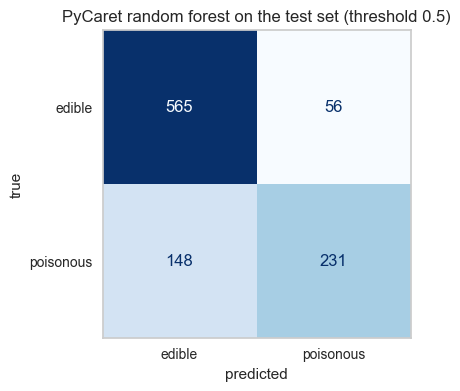

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(test_pred[TARGET], (p_poisonous >= 0.5).astype(int),
                                        display_labels=["edible", "poisonous"], cmap="Blues", colorbar=False, ax=ax)
ax.set(title="PyCaret random forest on the test set (threshold 0.5)", xlabel="predicted", ylabel="true")
ax.grid(False)
plt.show()

**Interpretation**
- The test scores are in line with cross-validation (AUC 0.84 on test vs. 0.83 in CV), so the random forest is not overfitting in a way that hurts: its deep trees fit the training set almost perfectly, but that does not carry over as an optimistic test score, thanks to the averaging.
- Compared with the baseline (notebook 03): accuracy rises from 67% to 80% and AUC from 0.71 to 0.84, with **far fewer false alarms** (56 instead of 174). But recall is about the same (0.61 vs. 0.60): the random forest still misses about 150 of the 379 poisonous mushrooms. It is a much better model that uses the wrong threshold for our purpose, because it was trained without class weights and threshold 0.5 treats both errors as equally bad.
- So the next gain is clear: with this AUC, lowering the threshold (or using class weights) should raise recall a lot while keeping precision acceptable. That is the first thing to do in `05`.

## 6. What does the random forest look at?

The feature importance of a random forest measures how much each feature reduces impurity over all splits in all trees (mean decrease in impurity). We compare it with what the logistic regression in notebook 03 relied on.

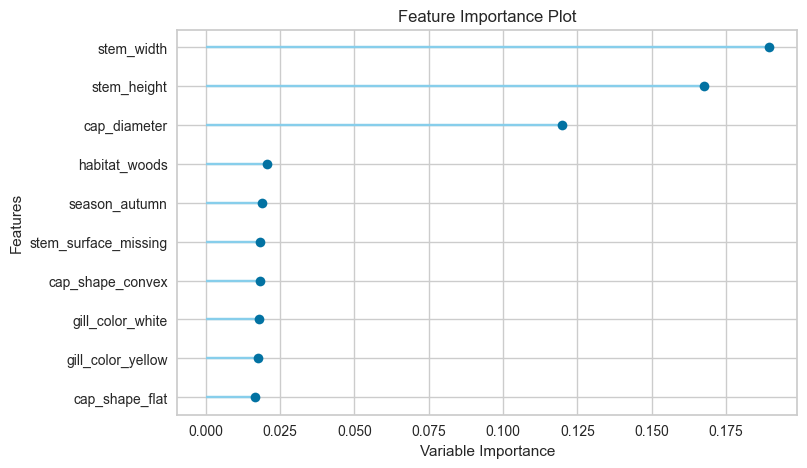

In [8]:
plot_model(best_model, plot="feature")

**Interpretation**
- The random forest relies mostly on the **three size measures**, the features the logistic regression hardly used (small coefficients in notebook 03). The EDA showed that each size on its own separates the classes only weakly (small effect sizes, EDA 6.4), but trees can combine them with each other and with categories ("small cap **and** thin stem **and** woods"). That is where the jump from AUC 0.71 to 0.84 comes from.
- A caveat: impurity-based importance is biased towards features with many possible split points, like continuous measurements. One-hot columns can only be split once. So the ranking overstates the numerical features somewhat; permutation importance (in `07_model_comparison.ipynb`) is a fairer check.

## 7. Saving the model

`save_model` stores the complete PyCaret pipeline (imputation, encoding, transformation, scaling and the random forest) as one `.pkl` file.

**Why not `finalize_model`?** PyCaret's usual last step retrains the model on train **and** test data together. For deployment that can make sense, but then the test set is no longer unseen and the model would not be comparable with the others in `07_model_comparison.ipynb`. So we save the model trained on the training set only.

This model is saved for the comparison, not for deployment: loading it requires PyCaret in the API. The deployed model will be a plain scikit-learn pipeline from the `05` notebooks, like the baseline.

In [9]:
save_model(best_model, str(MODEL_PATH), verbose=False)
size_mb = MODEL_PATH.with_suffix(".pkl").stat().st_size / 1e6
print(f"Saved {MODEL_PATH.with_suffix('.pkl')}  ({size_mb:.1f} MB, GitHub limit is 100 MB)")

Saved models\mushroom_pycaret_rf.pkl  (17.4 MB, GitHub limit is 100 MB)


## 8. Storing the metrics

We add the test result to the shared `models/metrics.csv` (rows of this notebook are replaced when it is run again) and show all models so far.

In [10]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,naive (always edible),03_model_baseline,0.5,0.621,0.000,0.000,0.000,0.50,379,0
1,logistic regression (balanced),03_model_baseline,0.5,0.674,0.599,0.566,0.582,0.71,152,174
2,PyCaret random forest (default),04_model_automl,0.5,0.796,0.609,0.805,0.694,0.84,148,56


## 9. Conclusion & next steps

- **Tree ensembles are the right model family** for this data: random forest, LightGBM and extra trees lead the comparison (AUC 0.79–0.83 in cross-validation), linear models trail far behind (≈ 0.69). This confirms the EDA (overlapping classes, weak single features) and the baseline notebook.
- **PyCaret's best model** is the default random forest: test accuracy ≈ 80%, AUC ≈ 0.84 (baseline: 67%, 0.71), and only a third of the baseline's false alarms.
- **Automatic tuning and blending did not help.** PyCaret's random search is limited to shallow trees, which do worse here; blending three similar tree models adds nothing.
- **Recall is the open problem**: even the best model misses about 40% of the poisonous mushrooms at threshold 0.5.

**Plan for the `05_model_*` notebooks** (tuning with cross-validation on the training set only):
- Tune the **random forest** and **gradient boosting (LightGBM or scikit-learn's `HistGradientBoostingClassifier`)** with our own search spaces, including deep trees for the forest.
- **Choose the decision threshold** with cross-validation for a target recall on poisonous mushrooms (for example ≥ 0.85), then report the precision that costs.
- Test the open questions from the data prep notebook: KNN/iterative imputation of `cap_diameter`, dropping `spore_print_color`, removing suspected flipped labels from the training set.